# Fundamentos de Álgebra Linear com PyTorch

Este notebook serve como uma introdução aos conceitos fundamentais da Álgebra Linear, a matemática dos dados. A compreensão profunda destes conceitos é um pré-requisito para o estudo avançado de qualquer campo da Inteligência Artificial.

## 1. Escalares, Vetores, Matrizes e Tensores

A Álgebra Linear lida fundamentalmente com vetores. No entanto, é útil começar com as estruturas que os englobam.

-   **Escalar**: Um único número, como $x \in \mathbb{R}$.
-   **Vetor**: Um array de números ordenados. Um vetor $v \in \mathbb{R}^n$ possui $n$ componentes, $v = [v_1, v_2, ..., v_n]$. Geralmente, nos referimos a ele como um vetor coluna:
$$ v = \begin{bmatrix} v_1 \\ v_2 \\ \vdots \\ v_n \end{bmatrix} $$
-   **Matriz**: Um array bidimensional de números. Uma matriz $A \in \mathbb{R}^{m \times n}$ tem $m$ linhas e $n$ colunas.
$$ A = \begin{bmatrix}
A_{1,1} & A_{1,2} & \cdots & A_{1,n} \\
A_{2,1} & A_{2,2} & \cdots & A_{2,n} \\
\vdots & \vdots & \ddots & \vdots \\
A_{m,1} & A_{m,2} & \cdots & A_{m,n}
\end{bmatrix} $$
-   **Tensor**: É uma generalização de um escalar (tensor de ordem 0), um vetor (tensor de ordem 1) e uma matriz (tensor de ordem 2) para um número arbitrário de dimensões (ordem $d$).

In [1]:
import torch

# Verificando a versão do PyTorch
print(f"Versão do PyTorch: {torch.__version__}")

Versão do PyTorch: 2.10.0


In [2]:
# Escalar (Tensor de ordem 0)
escalar = torch.tensor(3.14)
print("Escalar:")
print(escalar)
print("Ordem (ndim):", escalar.ndim)
print("Shape:", escalar.shape)

Escalar:
tensor(3.1400)
Ordem (ndim): 0
Shape: torch.Size([])


In [3]:
# Vetor (Tensor de ordem 1)
vetor = torch.tensor([1, 2, 3])
print("Vetor:")
print(vetor)
print("Ordem (ndim):", vetor.ndim)
print("Shape:", vetor.shape)

Vetor:
tensor([1, 2, 3])
Ordem (ndim): 1
Shape: torch.Size([3])


In [4]:
# Matriz (Tensor de ordem 2)
matriz = torch.tensor([[1, 2], [3, 4], [5, 6]])
print("Matriz:")
print(matriz)
print("Ordem (ndim):", matriz.ndim)
print("Shape:", matriz.shape) # 3 linhas, 2 colunas

Matriz:
tensor([[1, 2],
        [3, 4],
        [5, 6]])
Ordem (ndim): 2
Shape: torch.Size([3, 2])


## 2. Criação e Manipulação de Tensores em PyTorch

Embora possamos criar tensores a partir de listas Python, PyTorch oferece funções otimizadas para criar tensores comumente utilizados e para manipular seu formato.

### Funções de Criação
- `torch.ones(shape)`: Cria um tensor preenchido com o valor 1.
- `torch.zeros(shape)`: Cria um tensor preenchido com o valor 0.
- `torch.rand(shape)`: Cria um tensor com valores aleatórios de uma distribuição uniforme em $[0, 1)$.
- `torch.randn(shape)`: Cria um tensor com valores aleatórios de uma distribuição normal padrão (média 0, variância 1).
- `torch.arange(start, end, step)`: Cria um tensor com valores em um intervalo.
- `torch.linspace(start, end, steps)`: Cria um tensor com um número específico de valores (`steps`) espaçados linearmente entre `start` e `end`.

### Manipulação de Formato
- `.shape`: Atributo que retorna a dimensionalidade do tensor.
- `.reshape(new_shape)` / `.view(new_shape)`: Remodelam o tensor para um novo formato. `view` é mais rápido, mas só funciona em tensores contíguos na memória. `reshape` é mais flexível.
- `.flatten()`: Transforma um tensor multidimensional em um tensor 1D (um vetor).

In [5]:
x = torch.zeros(2, 3)
print("Tensor de Zeros (2, 3):\n", x)

Tensor de Zeros (2, 3):
 tensor([[0., 0., 0.],
        [0., 0., 0.]])


In [6]:
x = torch.ones(3, 2)
print("Tensor de Uns (3, 2):\n", x)

Tensor de Uns (3, 2):
 tensor([[1., 1.],
        [1., 1.],
        [1., 1.]])


In [7]:
x = torch.arange(0, 5)
print("Tensor com arange(0, 5):\n", x)

Tensor com arange(0, 5):
 tensor([0, 1, 2, 3, 4])


In [8]:
x = torch.linspace(0, 1, 5)
print("Tensor com linspace(0, 1, 5 passos):\n", x)

Tensor com linspace(0, 1, 5 passos):
 tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000])


In [9]:
x = torch.rand(2, 2)
print("Tensor Rand (dist. uniforme):\n", x)

Tensor Rand (dist. uniforme):
 tensor([[0.3341, 0.2465],
        [0.2585, 0.1051]])


In [10]:
x = torch.randn(2, 2)
print("Tensor Randn (dist. normal):\n", x)

Tensor Randn (dist. normal):
 tensor([[ 0.9192,  0.5824],
        [-0.6499, -0.9186]])


In [11]:
# Manipulação de formato
x = torch.arange(12)
print("--- Manipulação de Formato ---")
print("\nTensor original (x):\n", x)
print("Shape de x:", x.shape)

--- Manipulação de Formato ---

Tensor original (x):
 tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])
Shape de x: torch.Size([12])


In [12]:
# Reshape
x_reshaped = x.reshape(3, 4)
print("x com reshape(3, 4):\n", x_reshaped)
print("Shape de x_reshaped:", x_reshaped.shape)

x com reshape(3, 4):
 tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])
Shape de x_reshaped: torch.Size([3, 4])


In [13]:
# Flatten
x_flattened = x_reshaped.flatten()
print("x_reshaped achatado (flatten):\n", x_flattened)
print("Shape de x_flattened:", x_flattened.shape)

x_reshaped achatado (flatten):
 tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])
Shape de x_flattened: torch.Size([12])


## 3. Indexação e Fatiamento

Acessar e modificar subconjuntos de um tensor é uma operação rotineira. A sintaxe em PyTorch é similar à do NumPy, utilizando colchetes `[]` e o operador de fatiamento `:` (dois pontos). A indexação começa em zero.

-   Acessar um elemento: `T[i, j]` para o elemento na linha `i` e coluna `j`.
-   Acessar uma linha: `T[i, :]` para a linha `i` inteira.
-   Acessar uma coluna: `T[:, j]` para a coluna `j` inteira.
-   Acessar um subconjunto: `T[start_row:end_row, start_col:end_col]`.

In [14]:
# Criando um tensor 2D para os exemplos
T = torch.arange(20).reshape(5, 4)

print("Tensor original (5x4):\n", T)

Tensor original (5x4):
 tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11],
        [12, 13, 14, 15],
        [16, 17, 18, 19]])


In [15]:
# Acessando a linha de índice 1
T_linha_1 = T[1, :]
print("Linha de índice 1 (T[1, :]):\n", T_linha_1)

Linha de índice 1 (T[1, :]):
 tensor([4, 5, 6, 7])


In [16]:
# Acessando a coluna de índice 2
T_coluna_2 = T[:, 2]
print("Coluna de índice 2 (T[:, 2]):\n", T_coluna_2)

Coluna de índice 2 (T[:, 2]):
 tensor([ 2,  6, 10, 14, 18])


In [17]:
# Acessando o elemento na linha 3, coluna 1
T_el = T[3, 1]
print("Elemento em (3, 1):", T_el.item())

Elemento em (3, 1): 13


In [18]:
# Fatiando para obter um sub-bloco (linhas 1 e 2, colunas 0 e 1)
sub_bloco = T[1:3, 0:2]
print("Sub-bloco T[1:3, 0:2]:\n", sub_bloco)

Sub-bloco T[1:3, 0:2]:
 tensor([[4, 5],
        [8, 9]])


## 4. Redução de Tensores

Operações de redução agregam todos os valores de um tensor (ou de uma de suas dimensões) em um único valor, como soma, média, produto, etc.

- `torch.sum()`: Soma dos elementos.
- `torch.mean()`: Média dos elementos.
- `torch.prod()`: Produto dos elementos.
- `torch.max()` / `torch.min()`: Valores máximo e mínimo.

O argumento `dim` especifica a dimensão ao longo da qual a operação é aplicada.
- `dim=0`: Reduz ao longo das linhas (resultando em um valor por coluna).
- `dim=1`: Reduz ao longo das colunas (resultando em um valor por linha).

In [19]:
T = torch.arange(1, 7, dtype=torch.float32).reshape(2, 3)
print("Tensor original:\n", T)

# Redução total
print("\nSoma total (sum):", T.sum().item())
print("Média total (mean):", T.mean().item())

# Redução por dimensão
soma_colunas = T.sum(dim=0)
print("\nSoma ao longo das linhas (dim=0):", soma_colunas)

soma_linhas = T.sum(dim=1)
print("Soma ao longo das colunas (dim=1):", soma_linhas)

max_vals, max_indices = T.max(dim=1)
print("\nValores máximos por linha (dim=1):", max_vals)

Tensor original:
 tensor([[1., 2., 3.],
        [4., 5., 6.]])

Soma total (sum): 21.0
Média total (mean): 3.5

Soma ao longo das linhas (dim=0): tensor([5., 7., 9.])
Soma ao longo das colunas (dim=1): tensor([ 6., 15.])

Valores máximos por linha (dim=1): tensor([3., 6.])


## 5. Operações com Vetores

As operações mais básicas em Álgebra Linear são a adição de vetores e a multiplicação por escalar.

### Adição de Vetores
A soma de dois vetores $u, v \in \mathbb{R}^n$ é realizada elemento a elemento:
$$ w = u + v \quad \text{onde} \quad w_i = u_i + v_i $$

### Multiplicação por Escalar
A multiplicação de um vetor $v \in \mathbb{R}^n$ por um escalar $c \in \mathbb{R}$ resulta em um novo vetor onde cada elemento é multiplicado por $c$:
$$ w = c v \quad \text{onde} \quad w_i = c \cdot v_i $$
Geometricamente, isso "escala" (estica ou encolhe) o vetor $v$.

In [20]:
# Adição de Vetores
u = torch.tensor([1, 2, 3])
v = torch.tensor([10, 20, 30])
soma_vetores = u + v
print("Adição de Vetores (u + v):")
print(soma_vetores)

Adição de Vetores (u + v):
tensor([11, 22, 33])


In [21]:
# Multiplicação por Escalar
c = 2
w = c * u
print(f"Multiplicação por Escalar ({c} * u):")
print(w)

Multiplicação por Escalar (2 * u):
tensor([2, 4, 6])


### Exercícios: Criação e Manipulação de Tensores

1.  **Tensor Aleatório**: Crie um tensor de formato `(5, 5)` com números aleatórios provenientes de uma distribuição normal padrão.
2.  **Sequência Linear**: Crie um vetor (tensor 1D) que comece em -10, termine em 10 e contenha exatamente 50 pontos.
3.  **Remodelagem**: Crie um vetor com 100 elementos usando `torch.arange`. Em seguida, remodele-o para que tenha o formato `(10, 10)`.
4.  **Achatamento para Redes Neurais**: Crie um tensor que simule um lote (batch) de 4 imagens em escala de cinza de tamanho 28x28 (formato `(4, 28, 28)`). Em seguida, "achate" cada imagem para que o tensor final tenha o formato `(4, 784)`, que é um formato comum para a entrada de uma camada densa (fully-connected).

In [22]:
t5x5 = torch.randn(5, 5)
print(f"t5x5.shape: {t5x5.shape}")
print(f"t5x5: {t5x5}")

t1x10 = torch.linspace(-10, 10, 50)
print(f"t1x10.shape: {t1x10.shape}")
print(f"t1x10.len: {len(t1x10)}")
print(f"t1x10: {t1x10}")

t100 = torch.arange(100)
print(f"t100.shape: {t100.shape}")
print(f"t100: {t100}")

t10x10 = t100.reshape(10, 10)
print(f"t10x10.shape: {t10x10.shape}")
print(f"t10x10: {t10x10}")

batch = torch.randn(4, 28, 28) 
print(f"batch.shape: {batch.shape}")
print(f"batch: {batch}")

batch_flat = batch.flatten(start_dim=1)
print(f"batch_flat.shape: {batch_flat.shape}")
print(f"batch_flat: {batch_flat}")


t5x5.shape: torch.Size([5, 5])
t5x5: tensor([[ 0.2629, -0.8855, -0.8493,  1.2004,  0.3026],
        [ 0.9678,  1.6421, -1.2006, -1.6147, -0.6226],
        [ 0.4095,  0.5422, -1.0314,  0.1938,  0.5006],
        [ 0.3083, -0.5147,  0.4429,  0.9268, -1.1032],
        [-0.2044,  1.7354, -0.6625, -1.9902,  1.3913]])
t1x10.shape: torch.Size([50])
t1x10.len: 50
t1x10: tensor([-10.0000,  -9.5918,  -9.1837,  -8.7755,  -8.3673,  -7.9592,  -7.5510,
         -7.1429,  -6.7347,  -6.3265,  -5.9184,  -5.5102,  -5.1020,  -4.6939,
         -4.2857,  -3.8776,  -3.4694,  -3.0612,  -2.6531,  -2.2449,  -1.8367,
         -1.4286,  -1.0204,  -0.6122,  -0.2041,   0.2041,   0.6122,   1.0204,
          1.4286,   1.8367,   2.2449,   2.6531,   3.0612,   3.4694,   3.8776,
          4.2857,   4.6939,   5.1020,   5.5102,   5.9184,   6.3265,   6.7347,
          7.1429,   7.5510,   7.9592,   8.3673,   8.7755,   9.1837,   9.5918,
         10.0000])
t100.shape: torch.Size([100])
t100: tensor([ 0,  1,  2,  3,  4,  5,  6,

### Exercícios: Indexação e Fatiamento

Use o tensor abaixo para resolver os exercícios:
`T = torch.arange(25).reshape(5, 5)`

1.  **Seleção Simples**: Selecione e imprima o número `13` do tensor `T`.
2.  **Linha Inteira**: Selecione e imprima a terceira linha inteira (a que contém os elementos 10, 11, 12, 13, 14).
3.  **Sub-bloco Central**: Selecione e imprima o sub-bloco 3x3 que fica no centro da matriz `T`. O resultado deve ser:
    ```
    tensor([[ 6,  7,  8],
            [11, 12, 13],
            [16, 17, 18]])
    ```
4.  **Padrão Xadrez (Desafio)**: Selecione todos os elementos nas "casas pares" da matriz (e.g., T[0,0], T[0,2], T[0,4], T[2,0], etc.).
5.  **Modificação por Fatiamento**: Usando fatiamento, substitua o sub-bloco central 3x3 (o mesmo do exercício 3) por uma matriz de zeros do mesmo tamanho. Imprima o tensor `T` modificado.

In [23]:
T = torch.arange(25).reshape(5, 5)
print(f"T.shape: {T.shape}")
print(f"T: {T}")

print()
print(f"Seleção simples: T[2,3]: {T[2, 3]}")

print()
print(f"Linha Inteira: T[:,2]: {T[2, :]}")

print()
print(f"Sub-bloco Central: T[3:3,3:3]: {T[1:4, 1:4]}")

i = torch.arange(5)
j = torch.arange(5)
mask = (i.unsqueeze(1) + j.unsqueeze(0)) % 2 == 0
T[mask]
print()
print(f"Padrão Xadrez: T[mask]: {T[mask]}")

T_mod = T.clone()
T_mod[1:4, 1:4] = torch.zeros(3, 3)
print()
print(f"Modificação por Fatiamento: T[1:4, 1:4] = torch.zeros(3, 3): {T_mod}")


T.shape: torch.Size([5, 5])
T: tensor([[ 0,  1,  2,  3,  4],
        [ 5,  6,  7,  8,  9],
        [10, 11, 12, 13, 14],
        [15, 16, 17, 18, 19],
        [20, 21, 22, 23, 24]])

Seleção simples: T[2,3]: 13

Linha Inteira: T[:,2]: tensor([10, 11, 12, 13, 14])

Sub-bloco Central: T[3:3,3:3]: tensor([[ 6,  7,  8],
        [11, 12, 13],
        [16, 17, 18]])

Padrão Xadrez: T[mask]: tensor([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18, 20, 22, 24])

Modificação por Fatiamento: T[1:4, 1:4] = torch.zeros(3, 3): tensor([[ 0,  1,  2,  3,  4],
        [ 5,  0,  0,  0,  9],
        [10,  0,  0,  0, 14],
        [15,  0,  0,  0, 19],
        [20, 21, 22, 23, 24]])


### Exercícios: Redução de Tensores

Crie um tensor aleatório de formato `(4, 6)` para os exercícios a seguir.
`dados = torch.rand(4, 6)`

1.  **Média Geral**: Calcule a média de todos os elementos no tensor `dados`.
2.  **Soma por Coluna**: Calcule a soma de cada coluna. O resultado deve ser um vetor com 6 elementos.
3.  **Valor Mínimo por Linha**: Encontre o valor mínimo de cada linha. O resultado deve ser um vetor com 4 elementos.
4.  **Desvio Padrão**: Calcule o desvio padrão de cada coluna do tensor. (Dica: use `torch.std`).

In [24]:
dados = torch.rand(4, 6)
print(f"dados.shape: {dados.shape}")
print(f"dados: {dados}")

print()
print(f"Média Geral: dados.mean(): {dados.mean()}")

print()
print(f"Soma por Coluna: dados.sum(dim=0): {dados.sum(dim=0)}")

print()
print(f"Valor Mínimo por Linha: dados.min(dim=1): {dados.min(dim=1)}")

print()
print(f"Desvio Padrão: dados.std(dim=0): {dados.std(dim=0)}")


dados.shape: torch.Size([4, 6])
dados: tensor([[0.2415, 0.1138, 0.0573, 0.9791, 0.0956, 0.7161],
        [0.3960, 0.4953, 0.7463, 0.5867, 0.7391, 0.9845],
        [0.6644, 0.5733, 0.9562, 0.9179, 0.3584, 0.0597],
        [0.4384, 0.0037, 0.8335, 0.7958, 0.8974, 0.8298]])

Média Geral: dados.mean(): 0.561657726764679

Soma por Coluna: dados.sum(dim=0): tensor([1.7403, 1.1861, 2.5933, 3.2795, 2.0904, 2.5902])

Valor Mínimo por Linha: dados.min(dim=1): torch.return_types.min(
values=tensor([0.0573, 0.3960, 0.0597, 0.0037]),
indices=tensor([2, 0, 5, 1]))

Desvio Padrão: dados.std(dim=0): tensor([0.1747, 0.2800, 0.4033, 0.1731, 0.3636, 0.4071])


### Exercícios: Operações com Vetores

Considere os vetores  
$u = \begin{bmatrix}1 \\ 2\end{bmatrix}, \quad v = \begin{bmatrix}3 \\ -1\end{bmatrix}$  

1. **Adição e Subtração**: Calcule $u + v$ e $u - v$

2. **Multiplicação por Escalar**: Calcule $3u$

3. **Combinação Linear**: Calcule o vetor $w = 2u + 0.5v$ 

4. **Interpretação Geométrica (Teórico)**: Sem calcular, apenas descreva geometricamente, qual seria a relação entre o vetor $u$ e o vetor $z = -u$

In [25]:
u = torch.tensor([1, 2])
print(f"u: {u}")
v = torch.tensor([3, -1])
print(f"v: {v}")

print(f"u + v: {u + v}")
print(f"u - v: {u - v}")

print()
print(f"3u: {3 * u}")

w = 2 * u + 0.5 * v
print()
print(f"w = 2u + 0.5v: {w}")

print()
print(f"z = -u: representa geometricamente um vetor de mesmo tamanho que u mas com direção oposta")

u: tensor([1, 2])
v: tensor([ 3, -1])
u + v: tensor([4, 1])
u - v: tensor([-2,  3])

3u: tensor([3, 6])

w = 2u + 0.5v: tensor([3.5000, 3.5000])

z = -u: representa geometricamente um vetor de mesmo tamanho que u mas com direção oposta


## 6. Norma de um Vetor

A norma de um vetor é uma medida do seu "comprimento" ou "magnitude". A norma mais comum é a norma Euclidiana, ou norma $\ell_2$. Para um vetor $v \in \mathbb{R}^n$, a norma $\ell_2$, denotada por $||v||_2$, é calculada como:

$$ ||v||_2 = \sqrt{\sum_{i=1}^{n} v_i^2} = \sqrt{v_1^2 + v_2^2 + \cdots + v_n^2} $$

A norma de um vetor é sempre um valor não-negativo.

In [26]:
v = torch.tensor([3.0, 4.0])

# Calculando a norma l2
# sqrt(3^2 + 4^2) = sqrt(9 + 16) = sqrt(25) = 5
norma_v = torch.linalg.norm(v)

print("Vetor v:", v)
print("Norma l2 de v:", norma_v.item())

Vetor v: tensor([3., 4.])
Norma l2 de v: 5.0


In [27]:
# Vetor unitário: um vetor com norma igual a 1
# Para obter um vetor unitário, dividimos o vetor pela sua norma
v_unitario = v / norma_v
print("Vetor unitário de v:", v_unitario)
print("Norma do vetor unitário:", torch.linalg.norm(v_unitario).item())

Vetor unitário de v: tensor([0.6000, 0.8000])
Norma do vetor unitário: 1.0


## 7. Produto Interno e Ângulo entre Vetores

O produto interno (ou produto escalar, *dot product*) de dois vetores $u, v \in \mathbb{R}^n$ é a soma dos produtos dos elementos correspondentes:

$$ u^T v = u \cdot v = \sum_{i=1}^{n} u_i v_i $$

Ele possui uma propriedade geométrica fundamental que o relaciona ao ângulo $\theta$ entre os vetores:

$$ u \cdot v = ||u||_2 \ ||v||_2 \ \cos(\theta) $$

Podemos usar esta relação para encontrar o ângulo entre os vetores. Rearranjando a equação, temos:

$$ \cos(\theta) = \frac{u \cdot v}{||u||_2 \ ||v||_2} $$

E, finalmente, o ângulo $\theta$ é obtido pela função arco cosseno:

$$ \theta = \arccos\left(\frac{u \cdot v}{||u||_2 \ ||v||_2}\right) $$

Um produto interno de zero indica que os vetores são ortogonais ($\theta=90^\circ$).

In [28]:
u = torch.tensor([1, 2, 3])
v = torch.tensor([4, 5, 6])

# Calculando o produto interno
# 1*4 + 2*5 + 3*6 = 4 + 10 + 18 = 32
produto_interno = torch.dot(u, v)

print("Vetor u:", u)
print("Vetor v:", v)
print("Produto Interno (u . v):", produto_interno.item())

Vetor u: tensor([1, 2, 3])
Vetor v: tensor([4, 5, 6])
Produto Interno (u . v): 32


In [29]:
u = torch.tensor([1., 2.])
v = torch.tensor([3., 1.])

# 1. Calcular o produto interno
produto_interno = torch.dot(u, v)

# 2. Calcular a norma de cada vetor
norma_u = torch.linalg.norm(u)
norma_v = torch.linalg.norm(v)

# 3. Calcular o cosseno do ângulo
cos_theta = produto_interno / (norma_u * norma_v)

# 4. Calcular o ângulo em radianos usando arccos
theta_rad = torch.acos(cos_theta)

# Converter para graus
theta_deg = theta_rad * 180.0 / torch.pi

print(f"Cosseno do ângulo: {cos_theta.item():.2f}")
print(f"Ângulo em radianos: {theta_rad.item():.2f}")
print(f"Ângulo em graus: {theta_deg:.2f}°")

Cosseno do ângulo: 0.71
Ângulo em radianos: 0.79
Ângulo em graus: 45.00°


In [30]:
# Exemplo de vetores ortogonais
u_ort = torch.tensor([1., 0.])
v_ort = torch.tensor([0., 1.])
print("Produto Interno de vetores ortogonais:", torch.dot(u_ort, v_ort).item())

Produto Interno de vetores ortogonais: 0.0


## 8. Multiplicação de Matriz por Vetor

A multiplicação de uma matriz $A \in \mathbb{R}^{m \times n}$ por um vetor $v \in \mathbb{R}^n$ resulta em um novo vetor $b \in \mathbb{R}^m$. Essa operação representa uma **transformação linear**.

Pense na matriz $A$ como uma função que "transforma" o vetor $v$, que vive no espaço $\mathbb{R}^n$ (o espaço de entrada), e o mapeia para um novo vetor $b=Av$, que vive no espaço $\mathbb{R}^m$ (o espaço de saída). Essa transformação pode rotacionar, escalar ou cisalhar (shear) o vetor original.

O mecanismo desta transformação é que o vetor resultante $b$ é uma **combinação linear das colunas da matriz $A$**, onde os pesos dessa combinação são exatamente os **elementos do vetor $v$**:

$$ b = A v = v_1 \begin{bmatrix} A_{1,1} \\ \vdots \\ A_{m,1} \end{bmatrix} + v_2 \begin{bmatrix} A_{1,2} \\ \vdots \\ A_{m,2} \end{bmatrix} + \cdots + v_n \begin{bmatrix} A_{1,n} \\ \vdots \\ A_{m,n} \end{bmatrix} $$

In [31]:
# Matriz de transformação A (leva de R^2 para R^3)
A = torch.tensor([[1, 0],
                  [0, 1],
                  [1, 1]], dtype=torch.float32)

# Vetor original no espaço R^2
v = torch.tensor([2., 3.])

# Aplicar a transformação: A @ v
# O resultado será um novo vetor no espaço R^3
b = A @ v

print("Matriz de Transformação A (leva de R^2 para R^3):\n", A)
print("\nVetor original v (em R^2):\n", v)
print("\nVetor transformado b = A@v (em R^3):\n", b)

Matriz de Transformação A (leva de R^2 para R^3):
 tensor([[1., 0.],
        [0., 1.],
        [1., 1.]])

Vetor original v (em R^2):
 tensor([2., 3.])

Vetor transformado b = A@v (em R^3):
 tensor([2., 3., 5.])


In [32]:
# Verificando a intuição da combinação linear:
# b = 2 * A[:,0] + 3 * A[:,1]
b_combinacao_linear = v[0] * A[:, 0] + v[1] * A[:, 1]
print("Resultado via combinação linear das colunas:\n", b_combinacao_linear)

Resultado via combinação linear das colunas:
 tensor([2., 3., 5.])


## 9. Multiplicação de Matrizes: Composição de Transformações

Seguindo a mesma lógica, a multiplicação de duas matrizes, $C = AB$, representa a **composição de duas transformações lineares**.

Se uma matriz $B \in \mathbb{R}^{n \times p}$ transforma um vetor do espaço $\mathbb{R}^p$ para $\mathbb{R}^n$, e uma matriz $A \in \mathbb{R}^{m \times n}$ transforma um vetor de $\mathbb{R}^n$ para $\mathbb{R}^m$, então a matriz produto $C \in \mathbb{R}^{m \times p}$ representa a transformação única que leva diretamente do espaço $\mathbb{R}^p$ para $\mathbb{R}^m$.

Em outras palavras, aplicar a transformação $C$ a um vetor $v$ é o mesmo que aplicar primeiro a transformação $B$ e depois aplicar a transformação $A$ ao resultado:

$$ C v = (A B) v = A (B v) $$

Cada elemento $C_{ij}$ da matriz resultante é o produto interno da $i$-ésima linha da matriz $A$ com a $j$-ésima coluna da matriz $B$.

$$ C_{ij} = \sum_{k=1}^{n} A_{ik} B_{kj} $$

In [33]:
A = torch.tensor([[1, 2], [3, 4]]) # Matriz 2x2
B = torch.tensor([[10, 20], [30, 40]]) # Matriz 2x2

# Usando torch.matmul ou o operador @
C = torch.matmul(A, B)
# C = A @ B

print("Matriz A:\n", A)
print("\nMatriz B:\n", B)
print("\nResultado da multiplicação A @ B:\n", C)

# Verificando a não-comutatividade
print("\nResultado da multiplicação B @ A:\n", B @ A)

Matriz A:
 tensor([[1, 2],
        [3, 4]])

Matriz B:
 tensor([[10, 20],
        [30, 40]])

Resultado da multiplicação A @ B:
 tensor([[ 70, 100],
        [150, 220]])

Resultado da multiplicação B @ A:
 tensor([[ 70, 100],
        [150, 220]])


## 10. Distância entre Vetores

A distância entre dois pontos (representados por vetores) no espaço Euclidiano é o comprimento do vetor que conecta esses dois pontos. A distância Euclidiana entre dois vetores $u, v \in \mathbb{R}^n$ é definida como a norma do vetor diferença $u-v$:

$$ \text{dist}(u, v) = ||u - v||_2 = \sqrt{\sum_{i=1}^{n} (u_i - v_i)^2} $$

Este conceito é a base para muitos algoritmos de Machine Learning, como o k-Nearest Neighbors (k-NN).

In [34]:
u = torch.tensor([1., 5.])
v = torch.tensor([4., 1.])

# Calculando o vetor diferença
diferenca = u - v

# Calculando a norma do vetor diferença
distancia = torch.linalg.norm(diferenca)
# sqrt((1-4)^2 + (5-1)^2) = sqrt((-3)^2 + 4^2) = sqrt(9 + 16) = sqrt(25) = 5

print("Vetor u:", u)
print("Vetor v:", v)
print("Distância Euclidiana entre u e v:", distancia.item())

Vetor u: tensor([1., 5.])
Vetor v: tensor([4., 1.])
Distância Euclidiana entre u e v: 5.0


In [35]:
# PyTorch também tem uma função de conveniência para isso
distancia_pdist = torch.cdist(u.unsqueeze(0), v.unsqueeze(0))
print("Distância calculada com torch.cdist:", distancia_pdist.item())

Distância calculada com torch.cdist: 5.0


## 11. Broadcasting: Operações Inteligentes entre Tensores

Em muitas situações, desejamos realizar operações entre tensores que não possuem exatamente o mesmo formato. O caso mais simples é operar um escalar com um tensor (e.g., somar o número 5 a todos os elementos de uma matriz). Uma abordagem mais complexa seria somar um vetor a cada linha de uma matriz.

Broadcasting é um mecanismo poderoso e eficiente que realiza essas operações sem a necessidade de criar cópias dos dados na memória. Ele define um conjunto de regras para tratar tensores de formatos diferentes. A operação é possível se, ao comparar os formatos dos tensores da direita para a esquerda (a partir da última dimensão), uma das duas condições for verdadeira para cada par de dimensões:

1.  As dimensões são iguais.
2.  Uma das dimensões é 1 (um escalar é tratado como se tivesse dimensões de tamanho 1).

Se essas condições forem satisfeitas, o tensor com a dimensão menor é virtualmente "esticado" (broadcasted) para corresponder ao tamanho da dimensão do outro tensor.

**Exemplo:** Somar um vetor de formato `(3,)` a uma matriz de formato `(2, 3)`.

1.  Alinhamos os formatos pela direita:
    - Matriz: `2, 3`
    - Vetor: `   3`
2.  Comparando a última dimensão: `3` e `3`. Elas são iguais. (OK)
3.  Comparando a penúltima dimensão: `2` e (não existe). O PyTorch adiciona uma dimensão de tamanho 1 ao vetor:
    - Matriz: `2, 3`
    - Vetor:  `1, 3`
4.  Agora, comparamos a primeira dimensão: `2` e `1`. Como uma delas é `1`, a condição é satisfeita. (OK)

O vetor de formato `(1, 3)` é então "esticado" para o formato `(2, 3)` e a soma é realizada.

In [36]:
# Exemplo 0: Somando um escalar a um tensor (caso mais simples)
matriz_base = torch.arange(6).reshape(2, 3)
escalar = 100

# Formatos:
# Matriz:   (2, 3)
# Escalar:  () -> é "esticado" para o formato (2, 3)
resultado_escalar = matriz_base + escalar

print("--- Broadcasting de Escalar ---")
print("Matriz (2, 3):\n", matriz_base)
print("\nEscalar:", escalar)
print("\nResultado (Matriz + Escalar):\n", resultado_escalar)

--- Broadcasting de Escalar ---
Matriz (2, 3):
 tensor([[0, 1, 2],
        [3, 4, 5]])

Escalar: 100

Resultado (Matriz + Escalar):
 tensor([[100, 101, 102],
        [103, 104, 105]])


In [37]:
# Exemplo 1: Somando um vetor-linha a uma matriz
matriz = torch.ones((3, 4)) # Matriz 3x4
vetor_linha = torch.arange(4, dtype=torch.float32) # Vetor 1x4

# Formatos:
# Matriz:      (3, 4)
# Vetor-linha:    (4,) -> alinhado como (1, 4)
# O vetor é "esticado" para o formato (3, 4) e somado a cada linha
resultado = matriz + vetor_linha

print("--- Broadcasting de Vetor-Linha ---")
print("Matriz (3, 4):\n", matriz)
print("\nVetor-linha (4,):\n", vetor_linha)
print("\nResultado (Matriz + Vetor-linha):\n", resultado)

--- Broadcasting de Vetor-Linha ---
Matriz (3, 4):
 tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])

Vetor-linha (4,):
 tensor([0., 1., 2., 3.])

Resultado (Matriz + Vetor-linha):
 tensor([[1., 2., 3., 4.],
        [1., 2., 3., 4.],
        [1., 2., 3., 4.]])


In [38]:
# Exemplo 2: Somando um vetor-coluna a uma matriz
vetor_coluna = torch.arange(3, dtype=torch.float32).reshape(3, 1) # Vetor 3x1

# Formatos:
# Matriz:       (3, 4)
# Vetor-coluna: (3, 1)
# O vetor-coluna é "esticado" nas colunas para o formato (3, 4)
resultado_col = matriz + vetor_coluna

print("--- Broadcasting de Vetor-Coluna ---")
print("Matriz (3, 4):\n", matriz)
print("\nVetor-coluna (3, 1):\n", vetor_coluna)
print("\nResultado (Matriz + Vetor-coluna):\n", resultado_col)

--- Broadcasting de Vetor-Coluna ---
Matriz (3, 4):
 tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])

Vetor-coluna (3, 1):
 tensor([[0.],
        [1.],
        [2.]])

Resultado (Matriz + Vetor-coluna):
 tensor([[1., 1., 1., 1.],
        [2., 2., 2., 2.],
        [3., 3., 3., 3.]])


### Exercícios: Norma de um Vetor

1. **Cálculo de Norma $\ell_2$**: Calcule a norma Euclidiana ($\ell_2$) do vetor $v = \begin{bmatrix}5 \\ 12\end{bmatrix}$. O resultado deve ser um número inteiro.  

2. **Cálculo de Norma $\ell_1$**: A norma $\ell_1$ (ou norma de Manhattan) é a soma dos valores absolutos dos componentes do vetor:  
   $||v||_1 = \sum_{i=1}^{n} |v_i|$  
   Calcule a norma $\ell_1$ do mesmo vetor $v$ do exercício 1.  

3. **Vetor Unitário (Versor)**: Crie um vetor unitário (um vetor com norma $\ell_2$ igual a 1) a partir do vetor $w = \begin{bmatrix}1 \\ 2 \\ 3\end{bmatrix}$. Para isso, divida o vetor $w$ pela sua norma.  

4. **Verificação**: Verifique que o vetor que você criou no exercício 3 realmente tem norma igual a 1. (Pode haver um erro mínimo de ponto flutuante, e.g., 0.999999).  

In [39]:
v = torch.tensor([5., 12.])

print()
print(f"Norma Euclidiana de v: {torch.linalg.norm(v).item()}")

print()
print(f"Norma de Manhattan de v: {torch.linalg.norm(v, ord=1).item()}")

w = torch.tensor([1., 2., 3.])
w_unitario = w / torch.linalg.norm(w).item()

print()
print(f"Vetor unitário de w: {w_unitario}")

print()
print(f"Norma de w_unitário: {torch.linalg.norm(w_unitario).item():.4f}")



Norma Euclidiana de v: 13.0

Norma de Manhattan de v: 17.0

Vetor unitário de w: tensor([0.2673, 0.5345, 0.8018])

Norma de w_unitário: 1.0000


### Exercícios: Produto Interno e Ângulo

1. **Ortogonalidade**: Considere os vetores $u = \begin{bmatrix}2 \\ -1 \\ 1\end{bmatrix}$ e $v = \begin{bmatrix}1 \\ 2 \\ 0\end{bmatrix}$. Calcule o produto interno entre eles. Eles são ortogonais? Justifique.  

2. **Projeção**: O produto interno pode ser usado para calcular a projeção de um vetor sobre o outro. A projeção escalar de $u$ sobre $v$ é dada por  
   $\dfrac{u \cdot v}{||v||_2}$  
   Calcule essa projeção para os vetores do exercício anterior.  

3. **Ângulo Geométrico**: Crie dois vetores 2D quaisquer e calcule o ângulo (em graus) entre eles. Lembre que o ângulo pode ser obtido por  
   $\theta = \cos^{-1}\left(\dfrac{u \cdot v}{||u||_2 \, ||v||_2}\right)$.  
   Teste com vetores em que você já saiba o ângulo (ex: $[1,0]$ e $[0,1]$ devem dar $90^\circ$, $[1,0]$ e $[1,1]$ devem dar $45^\circ$).  

In [40]:
u = torch.tensor([2., -1., 1.])
v = torch.tensor([1., 2., 0.])

produto_interno = torch.dot(u, v)

print()
print(f"Produto interno de u e v: {torch.dot(u, v).item()}")

if (produto_interno.item() == 0.):
    print("u e v são ortogonais")
else:
    print("u e v não são ortogonais")

projecao_escalar = produto_interno / torch.linalg.norm(v).item()

print()
print(f"Projeção escalar de u sobre v: {projecao_escalar.item()}")

def angulo_entre_vetores(u, v):
    produto_interno = torch.dot(u, v)
    cos_theta = produto_interno / (torch.linalg.norm(u) * torch.linalg.norm(v))
    # clamp para evitar erros de arredondamento
    angulo_radianos = torch.acos(torch.clamp(cos_theta, -1.0, 1.0))
    return angulo_radianos * 180. / torch.pi

print()
print(f"Ângulo entre u e v: {angulo_entre_vetores(u, v).item():.2f} graus")

teste_angulos = torch.tensor([
    [[1., 0.], [0., 1.], [90., 0.]],
    [[1., 0.], [1., 1.], [45., 0.]],
    [[-1., -1.], [1., 1.], [180., 0.]],
    [[1., 0.], [0.5, (3**0.5)/2.], [60., 0.]]
])

print()
for i in range(teste_angulos.shape[0]):
    print(f"Ângulo entre teste_angulos[{i}]: {angulo_entre_vetores(teste_angulos[i,0], teste_angulos[i,1]).item():.2f} graus, e o valor esperado é {teste_angulos[i,2, 0].item():.2f} graus")





Produto interno de u e v: 0.0
u e v são ortogonais

Projeção escalar de u sobre v: 0.0

Ângulo entre u e v: 90.00 graus

Ângulo entre teste_angulos[0]: 90.00 graus, e o valor esperado é 90.00 graus
Ângulo entre teste_angulos[1]: 45.00 graus, e o valor esperado é 45.00 graus
Ângulo entre teste_angulos[2]: 180.00 graus, e o valor esperado é 180.00 graus
Ângulo entre teste_angulos[3]: 60.00 graus, e o valor esperado é 60.00 graus


### Exercícios: Multiplicação de Matriz por Vetor

1. **Transformação Simples**: Dada a matriz $A = \begin{bmatrix}2 & 0 \\ 0 & 1\end{bmatrix}$ e o vetor $v = \begin{bmatrix}3 \\ 5\end{bmatrix}$, calcule o produto $b = A v$. Como a matriz $A$ transformou o vetor $v$? (Observe o que aconteceu com cada componente de $v$).  

2. **Rotação**: Uma matriz de rotação em 2D que gira um vetor em $\theta$ graus no sentido anti-horário é dada por $R = \begin{bmatrix}\cos(\theta) & -\sin(\theta) \\ \sin(\theta) & \cos(\theta)\end{bmatrix}$. Crie essa matriz $R$ para uma rotação de $90^\circ$. Em seguida, aplique essa transformação ao vetor $v = \begin{bmatrix}2 \\ 0\end{bmatrix}$. Qual é o vetor resultante? O resultado faz sentido geometricamente?  

b = Av: tensor([6., 5.])
w: tensor([-8.7423e-08,  2.0000e+00])


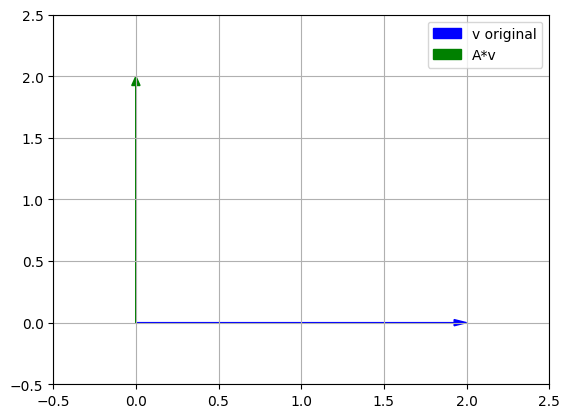

O resultado faz sentido geometricamente, no grafico podemos observar que o vetor rotacionou 90 graus.


In [41]:
A = torch.tensor( [[2., 0.], [0., 1.]])
v = torch.tensor([3., 5.])
b = torch.matmul(A, v)
print(f"b = Av: {b}")

theta_graus = torch.tensor(90.)
theta_rad = theta_graus * torch.pi / 180.   # 90° = π/2 rad

R = torch.tensor([[torch.cos(theta_rad), -torch.sin(theta_rad)], [torch.sin(theta_rad), torch.cos(theta_rad)]])
v = torch.tensor([2., 0.])
w = torch.matmul(R, v)
print(f"w: {w}")

# Para plotar as setas:

import matplotlib.pyplot as plt

ax = plt.gca()
ax.arrow(0, 0, v[0], v[1], head_width=0.05, color='blue', length_includes_head=True, label="v original")
ax.arrow(0, 0, w[0], w[1], head_width=0.05, color='green', length_includes_head=True, label="A*v")
plt.xlim(-.5, 2.5)
plt.ylim(-.5, 2.5)
plt.grid()
plt.legend()
plt.show()

print ("O resultado faz sentido geometricamente, no grafico podemos observar que o vetor rotacionou 90 graus.")

### Exercícios: Multiplicação de Matrizes

1.  **Compatibilidade**: Dadas as matrizes `A = torch.randn(4, 2)` e `B = torch.randn(2, 5)`, calcule o produto `C = A @ B`. Qual é o formato da matriz resultante? O produto `B @ A` é possível de ser calculado?
2.  **Não Comutatividade**: Crie duas matrizes quadradas `X` e `Y` de formato `(3, 3)` com números aleatórios. Mostre que `X @ Y` não é igual a `Y @ X`.
3.  **Matriz Identidade**: A matriz identidade `I` é o elemento neutro da multiplicação de matrizes ($AI = IA = A$). Crie uma matriz aleatória `A` de formato `(3, 3)` e uma matriz identidade `I` de mesmo formato (Dica: `torch.eye(3)`). Verifique que `A @ I` resulta na própria matriz `A`.

In [42]:
A = torch.randn(4, 2)
print()
print(f"A: {A}")

B = torch.randn(2, 5)
print()
print(f"B: {B}")

C = A @ B
print()
print(f"C=AxB: {C}")

print("B@A nao pode ser calculado por que nao cumpre com o requisito de numero de colunas de B ser igual ao numero de linhas de A.")

A = torch.randn(3, 3)
I = torch.eye(3)

C = A @ I
print()
print(f"C=AxI: {C}")

print()
print("A matriz identidade é o elemento neutro da multiplicação de matrizes, ou seja, A@I = I@A = A")
print()
print(f"A@I: {A@I}")

print()
print(f"I@A: {I@A}")


A: tensor([[-1.4351,  1.4835],
        [ 1.6402,  0.4578],
        [ 1.1968,  0.2876],
        [ 0.5522, -1.9621]])

B: tensor([[-1.1202, -1.9716, -0.9667, -1.1213, -0.6164],
        [ 0.3700, -0.0746,  0.4726, -0.4295, -0.2928]])

C=AxB: tensor([[ 2.1564,  2.7188,  2.0885,  0.9720,  0.4502],
        [-1.6679, -3.2680, -1.3692, -2.0358, -1.1450],
        [-1.2342, -2.3811, -1.0210, -1.4655, -0.8219],
        [-1.3445, -0.9424, -1.4611,  0.2235,  0.2341]])
B@A nao pode ser calculado por que nao cumpre com o requisito de numero de colunas de B ser igual ao numero de linhas de A.

C=AxI: tensor([[-0.7475,  0.2720,  0.2919],
        [ 0.0338, -1.3133,  0.9090],
        [ 0.4877,  1.6682,  1.5572]])

A matriz identidade é o elemento neutro da multiplicação de matrizes, ou seja, A@I = I@A = A

A@I: tensor([[-0.7475,  0.2720,  0.2919],
        [ 0.0338, -1.3133,  0.9090],
        [ 0.4877,  1.6682,  1.5572]])

I@A: tensor([[-0.7475,  0.2720,  0.2919],
        [ 0.0338, -1.3133,  0.9090],
   

### Exercícios: Distância entre Vetores

1.  **Distância Euclidiana**: Calcule a distância Euclidiana entre os pontos (vetores) `p1 = torch.tensor([2., 3.])` e `p2 = torch.tensor([5., 7.])`.
2.  **Ponto mais Próximo**: Dados três pontos, `A = torch.tensor([0., 0.])`, `B = torch.tensor([10., 0.])` e `C = torch.tensor([4., 5.])`, qual dos pontos (A ou B) está mais próximo do ponto C?
3.  **Impacto da Escala**: Calcule a distância entre `u = torch.tensor([1000., 1.])` e `v = torch.tensor([1001., 2.])`. Observe como a grande diferença na primeira dimensão domina completamente a distância total. Este é um dos motivos pelos quais a normalização de dados (vista nos exercícios de broadcasting) é tão importante em muitos algoritmos de IA.

In [43]:
print("\nExercicio 1: Distancia Euclidiana entre p1 e p2")
p1 = torch.tensor([2., 3.])
p2 = torch.tensor([5., 7.])

p2_p1 = p2 - p1

print("Vetor p2 - p1:")
print(p2_p1)
dist_p2_p1 = torch.linalg.norm(p2_p1)

print("Distancia Euclidiana entre p1 e p2:")
print(dist_p2_p1)

p1_p2 = p1 - p2

print("Vetor p1 - p2:")
print(p1_p2)
dist_p1_p2 = torch.linalg.norm(p1_p2)

print("Distancia Euclidiana entre p2 e p1:")
print(dist_p1_p2)

if (dist_p2_p1 != dist_p1_p2):
    print("Algo errado em nossas contas, a distancia entre p2 e p1 nao é igual a distancia entre p1 e p2")
else:
    print("Como esperado, a distancia entre p1 e p2 e vice-versa ")


print("\nExercicio 2: Ponto mais próximo")
A = torch.tensor([0., 0.])
B = torch.tensor([10., 0.])
C = torch.tensor([4., 5.])

dist_A_C = torch.linalg.norm(C - A)
dist_B_C = torch.linalg.norm(C - B)

print("Distancia Euclidiana entre A e C:")
print(dist_A_C)

print("Distancia Euclidiana entre B e C:")
print(dist_B_C)

if (dist_A_C < dist_B_C):
    print("A esta mais perto de C que B")
else:
    print("B esta mais perto de C que A")

print("\nExercicio 3: Impacto da escala")
u = torch.tensor([1000., 1.])
v = torch.tensor([1001., 2.])

w = v - u
dist_u_v = torch.linalg.norm(w)

print("u:")
print(u)

print("v:")
print(v)

print("w:")
print(w)

print("Distancia Euclidiana entre u e v:")
print(dist_u_v)

u = torch.tensor([1000., 1.])
v = torch.tensor([1050., 2.])

w = v - u
dist_u_v = torch.linalg.norm(w)

print("u:")
print(u)

print("v:")
print(v)

print("w:")
print(w)

print("Distancia Euclidiana entre u e v:")
print(dist_u_v)

print(
    """
    Com os numeros escolhidos originalmente, ambas dimensoes contribuem igualmente. Mas se utilizamos 1000 e 1050 por exemplo, vemos que a distancia possui contribuicao dominante da primeira dimensao.
    """
)



Exercicio 1: Distancia Euclidiana entre p1 e p2
Vetor p2 - p1:
tensor([3., 4.])
Distancia Euclidiana entre p1 e p2:
tensor(5.)
Vetor p1 - p2:
tensor([-3., -4.])
Distancia Euclidiana entre p2 e p1:
tensor(5.)
Como esperado, a distancia entre p1 e p2 e vice-versa 

Exercicio 2: Ponto mais próximo
Distancia Euclidiana entre A e C:
tensor(6.4031)
Distancia Euclidiana entre B e C:
tensor(7.8102)
A esta mais perto de C que B

Exercicio 3: Impacto da escala
u:
tensor([1000.,    1.])
v:
tensor([1001.,    2.])
w:
tensor([1., 1.])
Distancia Euclidiana entre u e v:
tensor(1.4142)
u:
tensor([1000.,    1.])
v:
tensor([1050.,    2.])
w:
tensor([50.,  1.])
Distancia Euclidiana entre u e v:
tensor(50.0100)

    Com os numeros escolhidos originalmente, ambas dimensoes contribuem igualmente. Mas se utilizamos 1000 e 1050 por exemplo, vemos que a distancia possui contribuicao dominante da primeira dimensao.
    


### Exercícios: Broadcasting

1.  **Normalização Z-score (Standard Scaler)**: Um passo comum em pré-processamento de dados é subtrair a média e dividir pelo desvio padrão de cada característica (coluna).
    - Crie uma matriz de dados "falsos" de formato `(10, 3)`.
    - Calcule a média de cada coluna (o resultado será um vetor de formato `(3,)`).
    - Calcule o desvio padrão de cada coluna (resultado também será `(3,)`).
    - Usando broadcasting, subtraia o vetor de médias da matriz de dados.
    - Usando broadcasting novamente, divida o resultado pelo vetor de desvios padrão.
    O resultado é a sua matriz normalizada.
2.  **Compatibilidade (Teórico)**: Sem usar código, diga se as operações de broadcasting a seguir são válidas. Se sim, qual o formato do tensor resultante?
    - Tensor A `(5, 3)` + Tensor B `(1, 3)`
    - Tensor A `(5, 3)` + Tensor B `(5, 1)`
    - Tensor A `(5, 3)` + Tensor B `(3,)`
    - Tensor A `(4, 1, 3)` + Tensor B `(4, 5, 3)`

In [44]:
sample_data = torch.randn(10, 3)
print("sample_data:")
print(sample_data)

media = torch.mean(sample_data, dim=0)
print("media:")
print(media)

desvio_padrao = torch.std(sample_data, dim=0)
print("desvio_padrao:")
print(desvio_padrao)

normalizado = (sample_data - media) / desvio_padrao
print("normalizado:")
print(normalizado)



sample_data:
tensor([[-0.9283, -1.2390,  1.2501],
        [ 1.6527,  0.5747, -1.2618],
        [-1.6728, -1.1998, -0.6480],
        [ 0.9369,  0.0952,  0.9368],
        [-1.7251, -1.1585, -0.5903],
        [ 1.4129,  0.8776, -0.0390],
        [-1.3308, -0.0819,  1.2652],
        [-1.6437, -0.8890,  0.9262],
        [ 0.5787,  0.0737,  0.3610],
        [ 0.0088,  0.5995,  0.3526]])
media:
tensor([-0.2711, -0.2348,  0.2553])
desvio_padrao:
tensor([1.3464, 0.8190, 0.8733])
normalizado:
tensor([[-0.4881, -1.2262,  1.1392],
        [ 1.4288,  0.9884, -1.7372],
        [-1.0411, -1.1783, -1.0343],
        [ 0.8972,  0.4029,  0.7804],
        [-1.0800, -1.1278, -0.9682],
        [ 1.2507,  1.3582, -0.3370],
        [-0.7871,  0.1866,  1.1564],
        [-1.0195, -0.7988,  0.7683],
        [ 0.6312,  0.3766,  0.1210],
        [ 0.2079,  1.0186,  0.1114]])


In [45]:
A = torch.randn(5, 3)
B = torch.randn(1, 3)
C = A + B
print("\n Caso 1:")
print("A:")
print(A)
print("B:")
print(B)
print("C:")
print(C)

A = torch.randn(5, 3)
B = torch.randn(5, 1)
C = A + B
print("\n Caso 2:")
print("A:")
print(A)
print("B:")
print(B)
print("C:")
print(C)


A = torch.randn(5, 3)
B = torch.randn(3)
C = A + B
print("\n Caso 3:")
print("A:")
print(A)
print("B:")
print(B)
print("C:")
print(C)

A = torch.randn(4, 1, 3)
B = torch.randn(4, 5, 3)
C = A + B
print("\n Caso 4:")
print("A:")
print(A)
print("B:")
print(B)
print("C:")
print(C)



 Caso 1:
A:
tensor([[-0.5816,  0.6747, -1.3526],
        [-1.5809, -0.3744,  1.3228],
        [-0.3545, -0.3076, -1.3976],
        [ 1.7770,  0.7447, -1.5436],
        [-1.0279, -0.0779,  1.5821]])
B:
tensor([[-0.9742,  1.0691,  0.1703]])
C:
tensor([[-1.5558,  1.7439, -1.1823],
        [-2.5551,  0.6947,  1.4931],
        [-1.3287,  0.7615, -1.2273],
        [ 0.8028,  1.8138, -1.3733],
        [-2.0021,  0.9912,  1.7524]])

 Caso 2:
A:
tensor([[ 1.0833,  1.3709,  0.6160],
        [-0.9894, -1.1337, -0.3062],
        [-1.6178,  1.6959,  2.0919],
        [ 1.6429,  1.5345,  1.5843],
        [-1.3068,  0.0302,  1.2978]])
B:
tensor([[0.4956],
        [1.0168],
        [0.1957],
        [0.0092],
        [0.9373]])
C:
tensor([[ 1.5788,  1.8664,  1.1116],
        [ 0.0274, -0.1169,  0.7106],
        [-1.4221,  1.8916,  2.2876],
        [ 1.6521,  1.5437,  1.5935],
        [-0.3695,  0.9675,  2.2351]])

 Caso 3:
A:
tensor([[ 0.2901, -0.3329, -0.6198],
        [-0.1852,  1.5558, -0.7075],
  